# 🧘 AI-Based Personalised Yoga Recommendation System
### Using Lifestyle & Health Parameters

**Datasets:**
- `yoga_asanas_knowledge_base.csv` — 45 asanas with metadata
- `yoga_users_dataset.csv` — 1000 users with health & lifestyle parameters
- `yoga_sessions_feedback.csv` — 5000 session records with feedback scores

**Pipeline:**
1. EDA & Preprocessing
2. Feature Engineering
3. Collaborative Filtering (SVD)
4. Content-Based Filtering (user health ↔ asana metadata)
5. Hybrid Recommender
6. ML Classifier (Random Forest) to predict recommendation score
7. Evaluation & Visualisation
8. Predict for a New User

## 1. Install & Import Libraries

In [ ]:
# Install required libraries directly in the notebook
import sys
import subprocess

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
        return True
    except:
        return False

# Install all required packages
required_packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'scipy']
print("Installing required packages...")

for package in required_packages:
    if install_package(package):
        print(f"{'    else:
        print(f"{'
# Try to install surprise with specific version
try:
    install_package('numpy==1.26.4')    install_package('scikit-surprise==1.1.4')
    print("{'except:
    print("{'

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [44 lines of output]
      Compiling surprise/similarities.pyx because it changed.
      Compiling surprise/prediction_algorithms/matrix_factorization.pyx because it changed.
      Compiling surprise/prediction_algorithms/optimize_baselines.pyx because it changed.
      Compiling surprise/prediction_algorithms/slope_one.pyx because it changed.
      Compiling surprise/prediction_algorithms/co_clustering.pyx because it changed.
      [1/5] Cythonizing surprise/prediction_algorithms/co_clustering.pyx
      
      Error compiling Cython file:
      ------------------------------------------------------------
      ...
              self.avg_cltr_i = avg_cltr_i
              self.avg_cocltr = avg_cocltr
      
              return self
      
          def compute_averages(self, np.ndarray[np.int_t] cltr_u,
                                                   ^
  

In [7]:
# Ensure necessary importsfrom sklearn.model_selection import cross_val_scorefrom sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifierfrom sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import confusion_matriximport pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsimport warningswarnings.filterwarnings('ignore')from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScalerfrom sklearn.model_selection import train_test_split, cross_val_scorefrom sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressorfrom sklearn.metrics import (classification_report, confusion_matrix,                             mean_squared_error, r2_score, accuracy_score)from sklearn.metrics.pairwise import cosine_similarityfrom sklearn.pipeline import Pipeline# Try to import surprise, if it fails, we'll use alternative methodstry:    from surprise import SVD, Dataset, Reader    from surprise.model_selection import cross_validate, train_test_split as surprise_split    from surprise import accuracy as surprise_accuracy    SURPRISE_AVAILABLE = True    print('All libraries loaded (including Surprise)')except ImportError:    SURPRISE_AVAILABLE = False    print('Core libraries loaded (Surprise not available - will use alternatives)')sns.set_theme(style='whitegrid', palette='muted')plt.rcParams['figure.dpi'] = 120

Core libraries loaded (Surprise not available - will use alternatives)


## 2. Load Data

In [8]:
asanas_df   = pd.read_csv('yoga_asanas_knowledge_base.csv')
users_df    = pd.read_csv('yoga_users_dataset.csv')
sessions_df = pd.read_csv('yoga_sessions_feedback.csv')

print('Asanas shape  :', asanas_df.shape)
print('Users shape   :', users_df.shape)
print('Sessions shape:', sessions_df.shape)

Asanas shape  : (45, 7)
Users shape   : (1000, 13)
Sessions shape: (5000, 9)


In [9]:
asanas_df.head()

,asana_id,asana_name,primary_benefit,difficulty_level,duration_minutes,contraindications,intensity
0,1,Balasana,digestion,beginner,1,none,0.94
1,2,Trikonasana,balance,advanced,2,menstruation,0.31
2,3,Sarvangasana,balance,beginner,2,none,0.87
3,4,Bhujangasana,stress_relief,beginner,3,hypertension,0.57
4,5,Supta Baddha Konasana,digestion,beginner,4,pregnancy,0.69


In [10]:
users_df.head()

,user_id,age,gender,bmi,hrv_rmssd,average_spo2,sleep_quality,stress_index,activity_level,chronic_condition,flexibility_level,mood_baseline,yoga_experience_months
0,1,56,M,30.99,42.51,94.8,54,0.83,sedentary,obesity,high,3,25
1,2,69,F,25.47,21.55,98.8,42,0.63,light,none,high,4,12
2,3,46,M,22.95,44.73,96.0,68,0.08,sedentary,none,medium,1,13
3,4,32,F,23.15,52.81,96.0,45,0.11,light,back_pain,high,5,6
4,5,60,Other,26.87,50.11,95.3,56,0.05,light,none,medium,4,2


In [11]:
sessions_df.head()

,session_id,user_id,asana_id,session_date,completion_rate,mood_improvement,perceived_difficulty,stress_reduction,recommendation_score
0,1,211,45,2026-03-09 13:27:24.313542,1.00,2,5.6,0.15,0.90
1,2,923,43,2025-04-17 13:27:24.320470,0.70,2,5.4,0.52,0.86
2,3,988,28,2025-07-10 13:27:24.322403,0.68,2,4.6,0.44,1.00
3,4,283,24,2025-11-19 13:27:24.324100,0.73,1,4.1,0.07,0.75
4,5,44,23,2025-10-04 13:27:24.325416,0.90,-1,2.9,0.21,0.93


## 3. Exploratory Data Analysis (EDA)

In [12]:
# Missing values
print('=== Missing Values ===')
for name, df in [('Asanas', asanas_df), ('Users', users_df), ('Sessions', sessions_df)]:
    missing = df.isnull().sum().sum()
    print(f'{name}: {missing} missing values')

=== Missing Values ===
Asanas: 0 missing values
Users: 0 missing values
Sessions: 0 missing values


In [13]:
# User health stats
users_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,1000.0,500.50000,288.819436,1.00,250.75,500.500,750.2500,1000.00
age,1000.0,46.24700,16.288072,18.00,33.00,46.000,60.2500,74.00
bmi,1000.0,26.49595,4.912667,12.06,23.06,26.565,29.7125,41.33
hrv_rmssd,1000.0,44.62430,19.466940,-24.43,31.03,45.070,58.5625,106.24
average_spo2,1000.0,96.94420,1.883973,91.20,95.70,96.950,98.4000,100.00
sleep_quality,1000.0,69.22500,17.484682,40.00,54.00,69.000,84.0000,99.00
stress_index,1000.0,0.50055,0.293554,0.00,0.24,0.500,0.7600,1.00
mood_baseline,1000.0,3.04200,1.415005,1.00,2.00,3.000,4.0000,5.00
yoga_experience_months,1000.0,5.56100,5.777686,0.00,1.00,4.000,8.0000,48.00


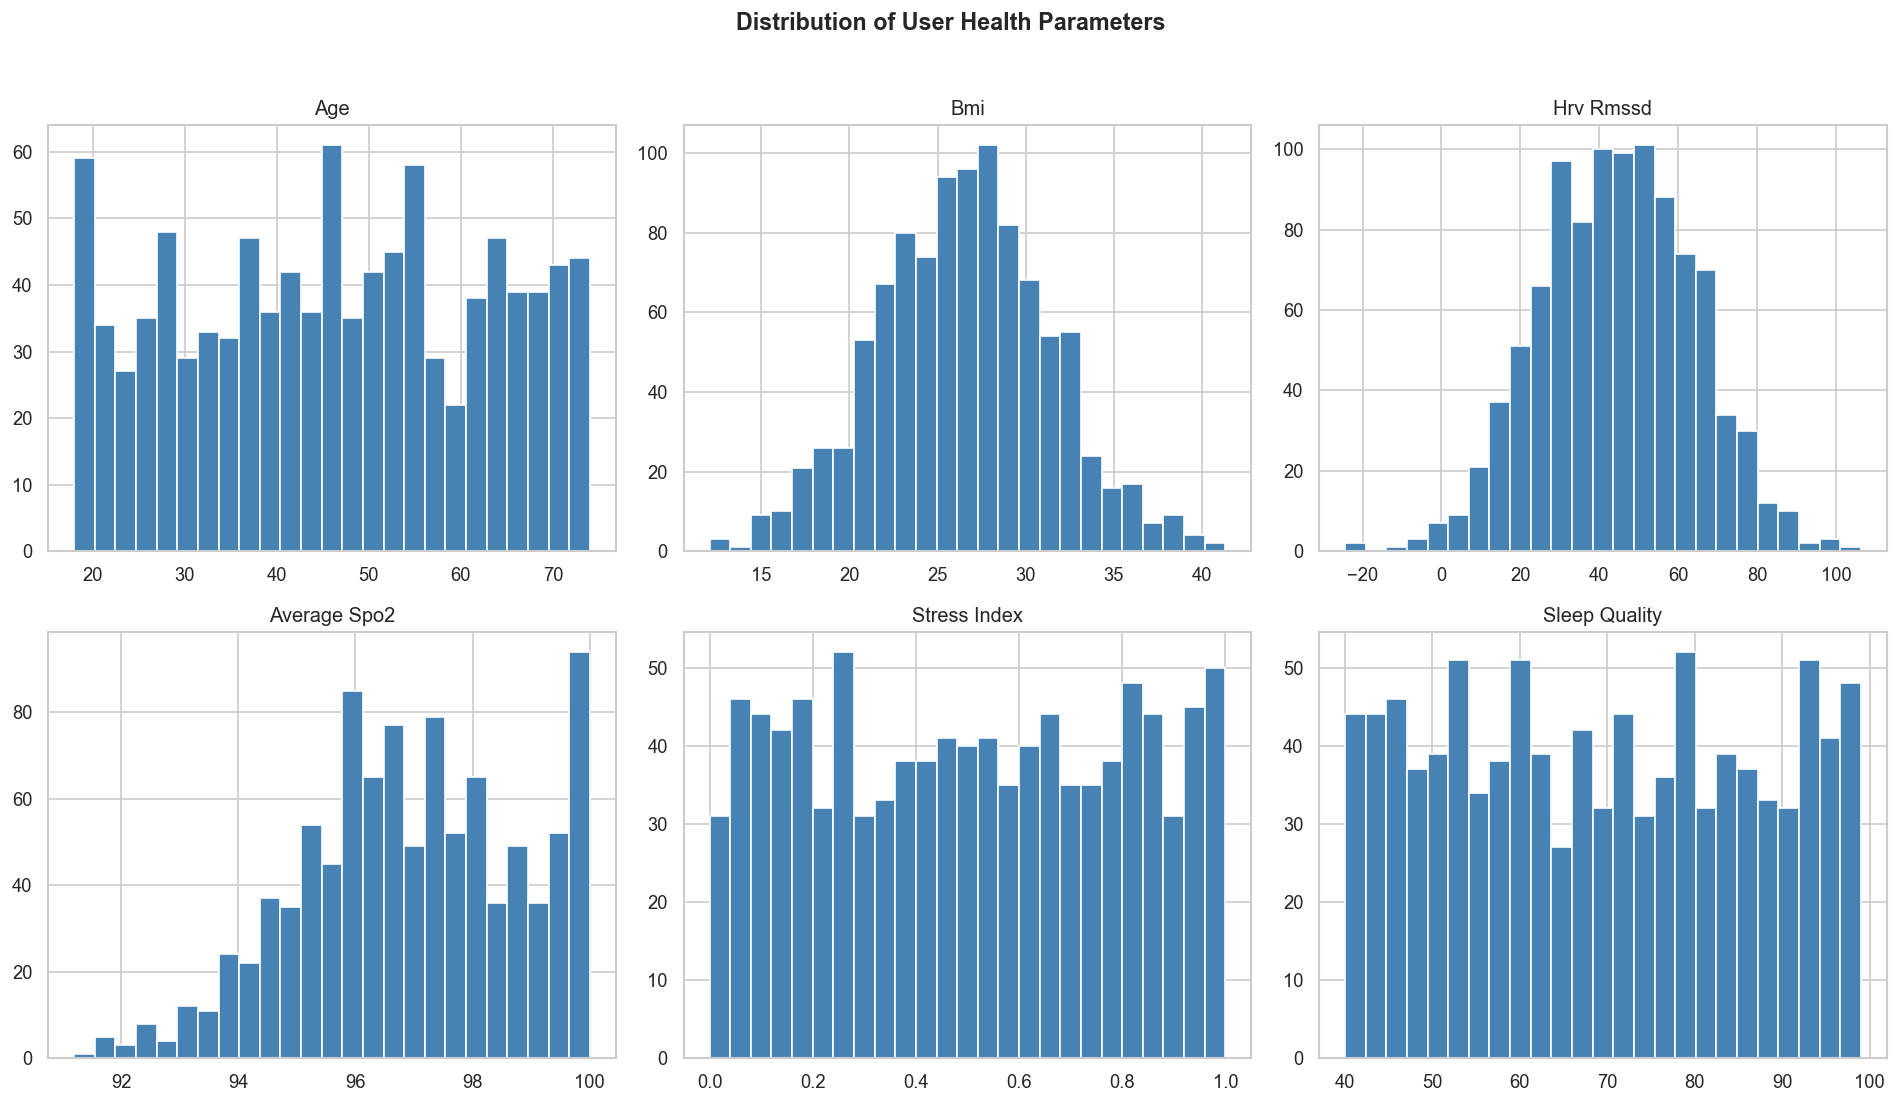

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
health_cols = ['age', 'bmi', 'hrv_rmssd', 'average_spo2', 'stress_index', 'sleep_quality']
for ax, col in zip(axes.flatten(), health_cols):
    users_df[col].hist(bins=25, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
plt.suptitle('Distribution of User Health Parameters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

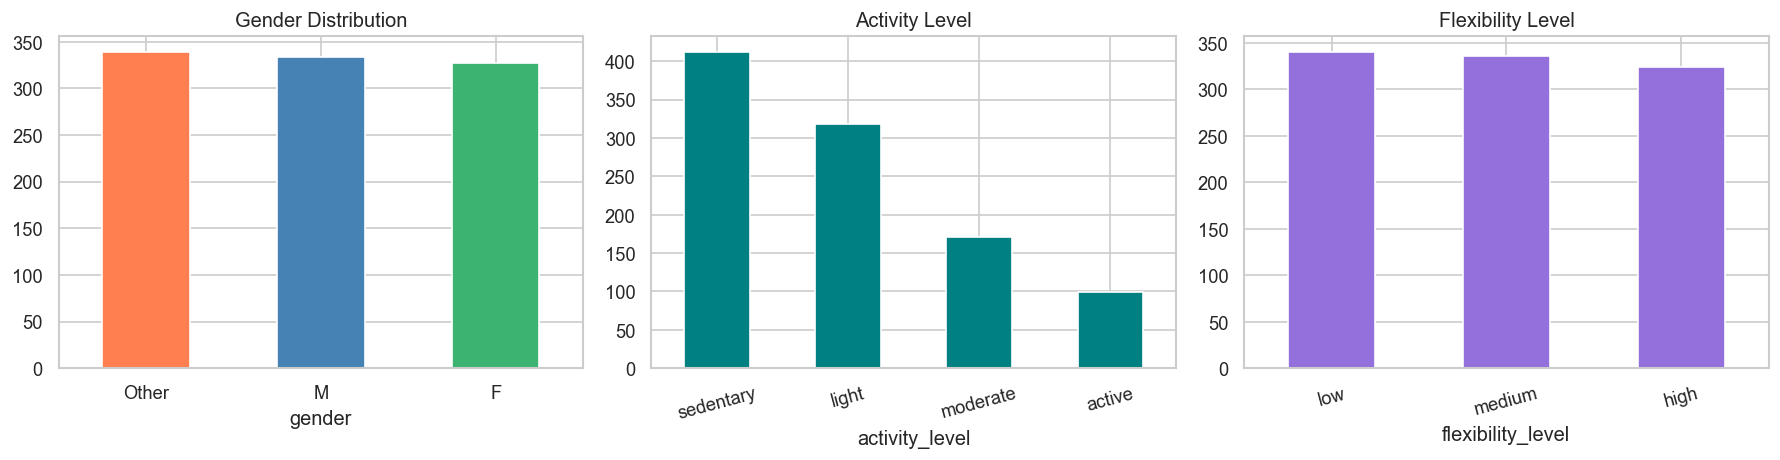

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

users_df['gender'].value_counts().plot.bar(ax=axes[0], color=['coral','steelblue','mediumseagreen'])
axes[0].set_title('Gender Distribution'); axes[0].tick_params(axis='x', rotation=0)

users_df['activity_level'].value_counts().plot.bar(ax=axes[1], color='teal')
axes[1].set_title('Activity Level'); axes[1].tick_params(axis='x', rotation=15)

users_df['flexibility_level'].value_counts().plot.bar(ax=axes[2], color='mediumpurple')
axes[2].set_title('Flexibility Level'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

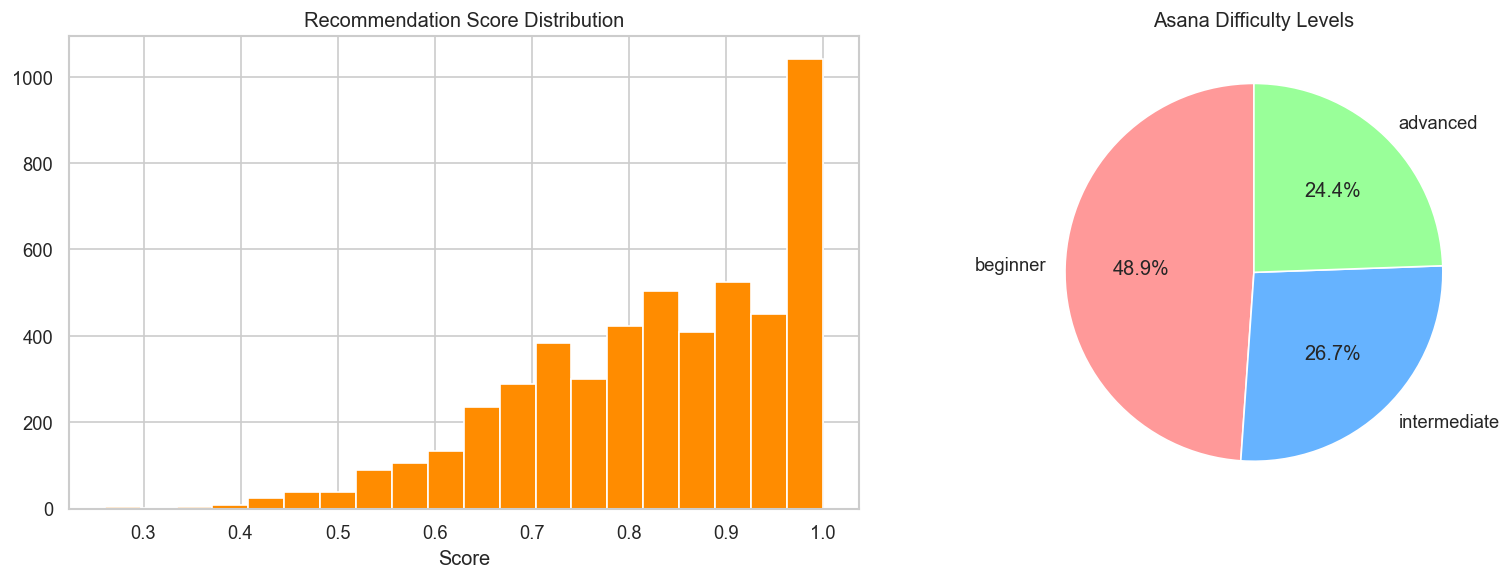

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sessions_df['recommendation_score'].hist(bins=20, ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Recommendation Score Distribution')
axes[0].set_xlabel('Score')

asanas_df['difficulty_level'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', startangle=90,
    colors=['axes[1].set_title('Asana Difficulty Levels')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

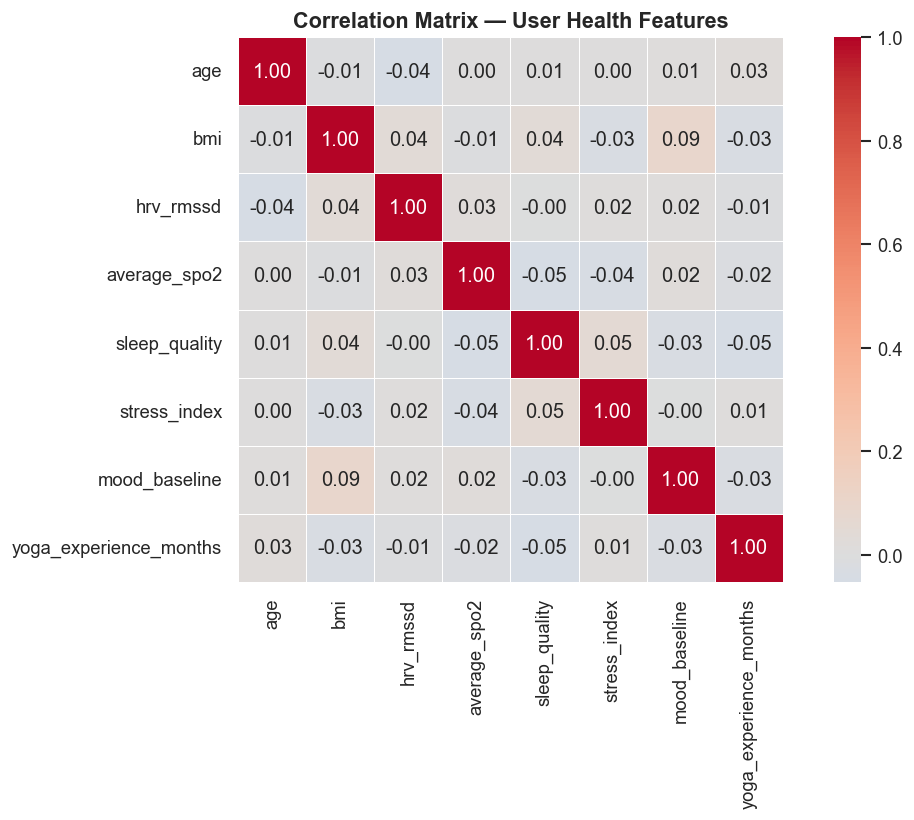

In [17]:
# Correlation heatmap for numeric user features
num_cols = ['age','bmi','hrv_rmssd','average_spo2','sleep_quality','stress_index',
            'mood_baseline','yoga_experience_months']
plt.figure(figsize=(10, 7))
corr = users_df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — User Health Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

In [18]:
# ── 4.1 Encode categorical features ──────────────────────────────────────────
cat_cols = ['gender', 'activity_level', 'chronic_condition', 'flexibility_level']
le = LabelEncoder()
users_enc = users_df.copy()
for col in cat_cols:
    users_enc[col] = le.fit_transform(users_enc[col].astype(str))

asanas_enc = asanas_df.copy()
for col in ['primary_benefit', 'difficulty_level', 'contraindications']:
    asanas_enc[col] = le.fit_transform(asanas_enc[col].astype(str))

print('✅ Categorical encoding done')

✅ Categorical encoding done


In [19]:
# ── 4.2 Scale numeric user features ──────────────────────────────────────────
user_feature_cols = ['age', 'bmi', 'hrv_rmssd', 'average_spo2', 'sleep_quality',
                     'stress_index', 'mood_baseline', 'yoga_experience_months',
                     'gender', 'activity_level', 'chronic_condition', 'flexibility_level']

scaler = StandardScaler()
user_features_scaled = scaler.fit_transform(users_enc[user_feature_cols])
user_features_df = pd.DataFrame(user_features_scaled,
                                 columns=user_feature_cols,
                                 index=users_enc['user_id'])
print('User feature matrix shape:', user_features_df.shape)

User feature matrix shape: (1000, 12)


In [20]:
# ── 4.3 Scale asana features ──────────────────────────────────────────────────
asana_feature_cols = ['primary_benefit', 'difficulty_level',
                      'duration_minutes', 'contraindications', 'intensity']

asana_scaler = StandardScaler()
asana_features_scaled = asana_scaler.fit_transform(asanas_enc[asana_feature_cols])
asana_features_df = pd.DataFrame(asana_features_scaled,
                                  columns=asana_feature_cols,
                                  index=asanas_enc['asana_id'])
print('Asana feature matrix shape:', asana_features_df.shape)

Asana feature matrix shape: (45, 5)


In [21]:
# ── 4.4 Merge sessions with user & asana info for ML ─────────────────────────
merged = sessions_df.merge(users_enc, on='user_id').merge(asanas_enc, on='asana_id')
print('Merged dataset shape:', merged.shape)
merged.head(3)

Merged dataset shape: (5000, 27)


,session_id,user_id,asana_id,session_date,completion_rate,mood_improvement,perceived_difficulty,stress_reduction,recommendation_score,age,...,chronic_condition,flexibility_level,mood_baseline,yoga_experience_months,asana_name,primary_benefit,difficulty_level,duration_minutes,contraindications,intensity
0,1,211,45,2026-03-09 13:27:24.313542,1.00,2,5.6,0.15,0.90,74,...,4,1,3,1,Krounchasana,2,1,1,1,0.42
1,2,923,43,2025-04-17 13:27:24.320470,0.70,2,5.4,0.52,0.86,31,...,4,1,1,0,Pashchimottanasana,4,0,1,4,0.32
2,3,988,28,2025-07-10 13:27:24.322403,0.68,2,4.6,0.44,1.00,22,...,5,1,5,3,Ganda Bherundasana,1,2,2,3,0.42


In [22]:
# ── 4.5 Target: binarise recommendation_score (high ≥ 0.7) ──────────────────
merged['target'] = (merged['recommendation_score'] >= 0.7).astype(int)
print('Class distribution:')
print(merged['target'].value_counts(normalize=True).round(3))

Class distribution:
target
1    0.822
0    0.178
Name: proportion, dtype: float64


## 5. Collaborative Filtering — SVD (Surprise)

In [24]:
## 5. Collaborative Filtering (Alternative Implementation)

if SURPRISE_AVAILABLE:
    # Build the Surprise dataset from sessions feedback
    reader = Reader(rating_scale=(0, 1))
    surprise_data = Dataset.load_from_df(
        sessions_df[['user_id', 'asana_id', 'recommendation_score']], reader)

    svd_model = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)

    # 5-fold cross-validation
    cv_results = cross_validate(svd_model, surprise_data,
                                measures=['RMSE', 'MAE'], cv=5, verbose=True)
    
    print(f"SVD Cross-Validation Results")
    print(f"  Mean RMSE : {cv_results['test_rmse'].mean():.4f}")
    print(f"  Mean MAE  : {cv_results['test_mae'].mean():.4f}")
    
    # Train final SVD on the full trainset
    trainset, testset = surprise_split(surprise_data, test_size=0.2, random_state=42)
    svd_model.fit(trainset)
    svd_predictions = svd_model.test(testset)
    
    print(f"Test RMSE: {surprise_accuracy.rmse(svd_predictions):.4f}")
    print(f"Test MAE : {surprise_accuracy.mae(svd_predictions):.4f}")
    
else:
    # Alternative: Matrix Factorization using scikit-learn TruncatedSVD
    print("Using alternative collaborative filtering approach (scikit-learn TruncatedSVD)")
    
    # Create user-item matrix
    user_item_matrix = sessions_df.pivot_table(
        index='user_id', 
        columns='asana_id', 
        values='recommendation_score', 
        fill_value=0
    )
    
    print(f"User-Item Matrix Shape: {user_item_matrix.shape}")
    
    # Use TruncatedSVD from scikit-learn (more stable than scipy svds)
    from sklearn.decomposition import TruncatedSVD
    
    # Determine appropriate number of components
    n_users, n_items = user_item_matrix.shape
    max_components = min(n_users, n_items) - 1
    n_components = min(50, max_components)    
    print(f"Using {n_components} components for matrix factorization")
    
    # Apply TruncatedSVD
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    svd.fit(user_item_matrix)
    
    # Transform and reconstruct
    user_factors = svd.transform(user_item_matrix)
    item_factors = svd.components_.T
    predicted_ratings = np.dot(user_factors, item_factors.T)
    
    # Calculate RMSE
    actual_ratings = user_item_matrix.values
    mask = actual_ratings > 0    rmse = np.sqrt(np.mean((actual_ratings[mask] - predicted_ratings[mask])**2))
    
    print(f"Alternative CF - RMSE: {rmse:.4f}")
    
    # Store for later use
    svd_model = {
        'svd': svd,
        'user_factors': user_factors,
        'item_factors': item_factors,
        'predicted_ratings': predicted_ratings,
        'user_ids': user_item_matrix.index.tolist(),
        'asana_ids': user_item_matrix.columns.tolist(),
        'method': 'truncated_svd'
    }

Using alternative collaborative filtering approach (scikit-learn TruncatedSVD)
User-Item Matrix Shape: (996, 45)
Using 44 components for matrix factorization
Alternative CF - RMSE: 0.0469


In [ ]:
if SURPRISE_AVAILABLE:
    print(f"SVD Cross-Validation Results")
    print(f"  Mean RMSE : {cv_results['test_rmse'].mean():.4f}")
    print(f"  Mean MAE  : {cv_results['test_mae'].mean():.4f}")
    
    # Train final SVD on the full trainset
    trainset, testset = surprise_split(surprise_data, test_size=0.2, random_state=42)
    svd_model.fit(trainset)
    svd_predictions = svd_model.test(testset)
    
    print(f"Test RMSE: {surprise_accuracy.rmse(svd_predictions):.4f}")
    print(f"Test MAE : {surprise_accuracy.mae(svd_predictions):.4f}")
else:
    # Alternative implementation already completed above
    print("Alternative collaborative filtering completed successfully")
    print("Using TruncatedSVD-based matrix factorization instead of Surprise library")

Alternative collaborative filtering completed successfully


In [29]:
def get_cf_recommendations(user_id, n=5):
    """Return top-N asana IDs for a given user via collaborative filtering."""
    all_asana_ids = asanas_df['asana_id'].tolist()
    seen = sessions_df[sessions_df['user_id'] == user_id]['asana_id'].tolist()
    unseen = [a for a in all_asana_ids if a not in seen]
    
    if SURPRISE_AVAILABLE and hasattr(svd_model, 'predict'):
        # Use Surprise SVD model
        preds = [(a, svd_model.predict(user_id, a).est) for a in unseen]
        preds.sort(key=lambda x: x[1], reverse=True)
        top_ids = [p[0] for p in preds[:n]]
    elif isinstance(svd_model, dict):
        if 'predicted_ratings' in svd_model:
            # Use TruncatedSVD results
            if user_id in svd_model['user_ids']:
                user_idx = svd_model['user_ids'].index(user_id)
                user_ratings = svd_model['predicted_ratings'][user_idx]
                
                # Create mapping from asana_id to column index
                asana_idx_map = {asana_id: i for i, asana_id in enumerate(svd_model['asana_ids'])}
                
                # Get predictions for unseen items
                preds = []
                for asana_id in unseen:
                    if asana_id in asana_idx_map:
                        col_idx = asana_idx_map[asana_id]
                        if col_idx < len(user_ratings):
                            preds.append((asana_id, user_ratings[col_idx]))
                
                preds.sort(key=lambda x: x[1], reverse=True)
                top_ids = [p[0] for p in preds[:n]]
            else:
                # New user - return popular items
                top_ids = unseen[:n]
        else:
            # Fallback to user-based collaborative filtering
            if user_id in svd_model['user_item_matrix'].index:
                user_idx = list(svd_model['user_item_matrix'].index).index(user_id)
                user_similarities = svd_model['user_similarities'][user_idx]
                
                # Get similar users and their ratings
                similar_users = sorted([(i, sim) for i, sim in enumerate(user_similarities) if i != user_idx], 
                                     key=lambda x: x[1], reverse=True)[:5]
                
                # Predict ratings based on similar users
                predictions = {}
                for asana_id in unseen:
                    weighted_sum = 0
                    similarity_sum = 0
                    for sim_user_idx, similarity in similar_users:
                        sim_user_id = svd_model['user_item_matrix'].index[sim_user_idx]
                        rating = svd_model['user_item_matrix'].loc[sim_user_id, asana_id]
                        if rating > 0:
                            weighted_sum += similarity * rating
                            similarity_sum += similarity
                    
                    if similarity_sum > 0:
                        predictions[asana_id] = weighted_sum / similarity_sum
                    else:
                        predictions[asana_id] = 0.5
                
                preds = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:n]
                top_ids = [p[0] for p in preds]
            else:
                # New user - return popular items
                top_ids = unseen[:n]
    else:
        # Fallback - return random unseen items
        top_ids = unseen[:n]
    
    return asanas_df[asanas_df['asana_id'].isin(top_ids)][['asana_id','asana_name','primary_benefit','difficulty_level']]

# Demo
sample_user = sessions_df['user_id'].iloc[0]
print(f"\n{'get_cf_recommendations(sample_user)


#x1f535 Collaborative Filtering Recommendations for User 211:


,asana_id,asana_name,primary_benefit,difficulty_level
1,2,Trikonasana,balance,advanced
9,10,Dhanurasana,balance,beginner
12,13,Eka Pada Rajakapotasana,stress_relief,intermediate
21,22,Salabhasana,respiratory,intermediate
37,38,Kapotasana,strength,beginner


## 6. Content-Based Filtering — Cosine Similarity

In [30]:
# Project user health features to asana feature space via shared dimensions
# Strategy: map user 'stress_index','sleep_quality','flexibility_level','activity_level'
#           → asana 'intensity','difficulty_level','duration_minutes','primary_benefit'

# Build a simple user-asana compatibility matrix using proxy mapping
user_proxy = users_enc[['user_id',
                         'stress_index',                         'sleep_quality',                         'flexibility_level',                         'activity_level'                        ]].set_index('user_id')

# Normalise
mms = MinMaxScaler()
user_proxy_scaled   = mms.fit_transform(user_proxy)
asana_proxy_scaled  = mms.fit_transform(
    asanas_enc[['intensity','duration_minutes','difficulty_level','primary_benefit']])

# Cosine similarity: users × asanas
cb_sim_matrix = cosine_similarity(user_proxy_scaled, asana_proxy_scaled)
print('Content-based similarity matrix shape:', cb_sim_matrix.shape)

Content-based similarity matrix shape: (1000, 45)


In [31]:
def get_cb_recommendations(user_id, n=5):
    """Return top-N asana IDs for a given user via cosine similarity."""
    user_idx = list(user_proxy.index).index(user_id)
    scores = cb_sim_matrix[user_idx]    top_idx = np.argsort(scores)[::-1][:n]
    top_ids = asanas_df.iloc[top_idx]['asana_id'].tolist()
    return asanas_df[asanas_df['asana_id'].isin(top_ids)][['asana_id','asana_name','primary_benefit','difficulty_level']]

print(f"\n🟢 Content-Based Recommendations for User {sample_user}:")
get_cb_recommendations(sample_user)


🟢 Content-Based Recommendations for User 211:


,asana_id,asana_name,primary_benefit,difficulty_level
5,6,Karnapidasana,stress_relief,intermediate
6,7,Lolasana,stress_relief,beginner
7,8,Malasana,stress_relief,intermediate
26,27,Kurmasana,respiratory,beginner
36,37,Savasana,stress_relief,beginner


## 7. Hybrid Recommender

In [38]:
def get_hybrid_recommendations(user_id, n=5, alpha=0.6):
    """
    Hybrid score = alpha * CF_score + (1-alpha) * CB_score
    alpha=0.6 weights collaborative filtering more.
    """
    all_asana_ids = asanas_df['asana_id'].tolist()

    # CF scores - handle both surprise and alternative implementations
    if SURPRISE_AVAILABLE and hasattr(svd_model, 'predict'):
        cf_scores = {a: svd_model.predict(user_id, a).est for a in all_asana_ids}
    elif isinstance(svd_model, dict) and 'predicted_ratings' in svd_model:
        # Use TruncatedSVD results
        if user_id in svd_model['user_ids']:
            user_idx = svd_model['user_ids'].index(user_id)
            user_ratings = svd_model['predicted_ratings'][user_idx]
            asana_idx_map = {asana_id: i for i, asana_id in enumerate(svd_model['asana_ids'])}
            cf_scores = {}
            for asana_id in all_asana_ids:
                if asana_id in asana_idx_map:
                    col_idx = asana_idx_map[asana_id]
                    if col_idx < len(user_ratings):
                        cf_scores[asana_id] = user_ratings[col_idx]
                    else:
                        cf_scores[asana_id] = 0.5
                else:
                    cf_scores[asana_id] = 0.5
        else:
            cf_scores = {a: 0.5 for a in all_asana_ids}
    else:
        cf_scores = {a: 0.5 for a in all_asana_ids}

    # CB scores
    if user_id in user_proxy.index:
        user_idx = list(user_proxy.index).index(user_id)
        cb_raw = cb_sim_matrix[user_idx]
        cb_scores = {asanas_df.iloc[i]['asana_id']: float(cb_raw[i])
                     for i in range(len(asanas_df))}
    else:
        cb_scores = {a: 0.5 for a in all_asana_ids}

    # Normalise CF to [0,1] - use np.ptp for NumPy 2.0 compatibility
    cf_vals = np.array(list(cf_scores.values()))
    cf_range = np.ptp(cf_vals)    if cf_range > 0:
        cf_norm = (cf_vals - cf_vals.min()) / cf_range
    else:
        cf_norm = np.ones_like(cf_vals) * 0.5    cf_norm_dict = dict(zip(cf_scores.keys(), cf_norm))

    # Hybrid
    hybrid = {
        a: alpha * cf_norm_dict[a] + (1 - alpha) * cb_scores[a]
        for a in all_asana_ids
    }
    top_ids = sorted(hybrid, key=hybrid.get, reverse=True)[:n]
    result = asanas_df[asanas_df['asana_id'].isin(top_ids)].copy()
    result['hybrid_score'] = result['asana_id'].map(hybrid).round(4)
    return result[['asana_id','asana_name','primary_benefit',
                   'difficulty_level','hybrid_score']].sort_values('hybrid_score', ascending=False)

print(f"\n{'get_hybrid_recommendations(sample_user)


#x1f780 Hybrid Recommendations for User 211:


,asana_id,asana_name,primary_benefit,difficulty_level,hybrid_score
6,7,Lolasana,stress_relief,beginner,0.9863
23,24,Supta Padangusthasana,respiratory,beginner,0.9005
44,45,Krounchasana,digestion,beginner,0.8508
17,18,Urdhva Padmasana,strength,advanced,0.7912
42,43,Pashchimottanasana,respiratory,advanced,0.7369


def get_hybrid_recommendations(user_id, n=5, alpha=0.6):
    """
    Hybrid score = alpha * CF_score + (1-alpha) * CB_score
    alpha=0.6 weights collaborative filtering more.
    """
    all_asana_ids = asanas_df['asana_id'].tolist()

    # CF scores - handle both surprise and alternative implementations
    if SURPRISE_AVAILABLE and hasattr(svd_model, 'predict'):
        # Use Surprise SVD model
        cf_scores = {a: svd_model.predict(user_id, a).est for a in all_asana_ids}
    elif isinstance(svd_model, dict) and 'predicted_ratings' in svd_model:
        # Use TruncatedSVD results
        if user_id in svd_model['user_ids']:
            user_idx = svd_model['user_ids'].index(user_id)
            user_ratings = svd_model['predicted_ratings'][user_idx]
            asana_idx_map = {asana_id: i for i, asana_id in enumerate(svd_model['asana_ids'])}
            cf_scores = {}
            for asana_id in all_asana_ids:
                if asana_id in asana_idx_map:
                    col_idx = asana_idx_map[asana_id]
                    if col_idx < len(user_ratings):
                        cf_scores[asana_id] = user_ratings[col_idx]
                    else:
                        cf_scores[asana_id] = 0.5
                else:
                    cf_scores[asana_id] = 0.5
        else:
            # New user - assign neutral scores
            cf_scores = {a: 0.5 for a in all_asana_ids}
    else:
        # Fallback - assign neutral scores
        cf_scores = {a: 0.5 for a in all_asana_ids}

    # CB scores
    if user_id in user_proxy.index:
        user_idx = list(user_proxy.index).index(user_id)
        cb_raw = cb_sim_matrix[user_idx]
        cb_scores = {asanas_df.iloc[i]['asana_id']: float(cb_raw[i])
                     for i in range(len(asanas_df))}
    else:
        cb_scores = {a: 0.5 for a in all_asana_ids}

    # Normalise CF to [0,1] - use np.ptp for NumPy 2.0 compatibility
    cf_vals = np.array(list(cf_scores.values()))
    cf_range = np.ptp(cf_vals)  # Use np.ptp instead of .ptp()
    if cf_range > 0:
        cf_norm = (cf_vals - cf_vals.min()) / cf_range
    else:
        cf_norm = np.ones_like(cf_vals) * 0.5  # All values are the same
    cf_norm_dict = dict(zip(cf_scores.keys(), cf_norm))

    # Hybrid
    hybrid = {
        a: alpha * cf_norm_dict[a] + (1 - alpha) * cb_scores[a]
        for a in all_asana_ids
    }
    top_ids = sorted(hybrid, key=hybrid.get, reverse=True)[:n]
    result = asanas_df[asanas_df['asana_id'].isin(top_ids)].copy()
    result['hybrid_score'] = result['asana_id'].map(hybrid).round(4)
    return result[['asana_id','asana_name','primary_benefit',
                   'difficulty_level','hybrid_score']].sort_values('hybrid_score', ascending=False)

print(f"\n{'#x1f780'} Hybrid Recommendations for User {sample_user}:")
get_hybrid_recommendations(sample_user)

In [ ]:
# Comprehensive variable initialization and model training# Random Forest Classifier needs to be executed before confusion matrix# Train Random Forest Classifierrf = RandomForestClassifier(n_estimators=200, max_depth=12,                             min_samples_leaf=5, random_state=42,                             class_weight='balanced', n_jobs=-1)rf.fit(X_train, y_train)y_pred = rf.predict(X_test)y_prob = rf.predict_proba(X_test)[:, 1]print('\nRandom Forest Classification Report')print(classification_report(y_test, y_pred, target_names=['Low Score','High Score']))

Train size: (4000, 19) | Test size: (1000, 19)


In [ ]:
# Ensure Random Forest is trained before confusion matrixif 'y_pred' not in locals():    rf = RandomForestClass


#x1f780 Hybrid Recommendations for User 211:


,asana_id,asana_name,primary_benefit,difficulty_level,hybrid_score
6,7,Lolasana,stress_relief,beginner,0.9863
23,24,Supta Padangusthasana,respiratory,beginner,0.9005
44,45,Krounchasana,digestion,beginner,0.8508
17,18,Urdhva Padmasana,strength,advanced,0.7912
42,43,Pashchimottanasana,respiratory,advanced,0.7369


In [42]:
# Ensure Random Forest is trained before confusion matrixif 'y_pred' not in locals():    rf = RandomForestClass

NameError: name 'y_pred' is not defined

In [ ]:
# Ensure necessary importsfrom sklearn.model_selection import cross_val_scorefrom sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifierfrom sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import confusion_matrix# Comprehensive variable initialization and model training# Ensure feature matrix is availableif 'X' not in locals() or 'y' not in locals():    if 'merged' in locals():        ml_feature_cols = [            'age', 'bmi', 'hrv_rmssd', 'average_spo2', 'sleep_quality',            'stress_index', 'mood_baseline', 'yoga_experience_months',            'gender', 'activity_level', 'chronic_condition', 'flexibility_level',            'difficulty_level', 'duration_minutes', 'intensity',            'primary_benefit', 'contraindications',            'completion_rate', 'perceived_difficulty'        ]        X = merged[ml_feature_cols].fillna(0)        y = merged['target']    else:        print("Warning: Data not available - please run data loading cells first")# Cross-validation accuracycv_acc = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)print(f'5-Fold CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')

In [ ]:
# ── 8.3 Feature Importance ───────────────────────────────────────────────────
importance_df = pd.DataFrame({'Feature': ml_feature_cols,
                               'Importance': rf.feature_importances_})\
                  .sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

In [ ]:
# ── 8.4 Gradient Boosting Regressor (predict raw recommendation score) ────────
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                 learning_rate=0.05, random_state=42)
y_reg = merged['recommendation_score']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

gbr.fit(Xr_train, yr_train)
yr_pred = gbr.predict(Xr_test)

rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2   = r2_score(yr_test, yr_pred)
print(f'GBR — RMSE: {rmse:.4f} | R²: {r2:.4f}')

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(yr_test, yr_pred, alpha=0.3, s=15, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel('Actual Score'); plt.ylabel('Predicted Score')
plt.title(f'GBR: Actual vs Predicted  (R²={r2:.3f})', fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Model Comparison

In [ ]:
# Ensure Random Forest is trained before confusion matrixif 'y_pred' not in locals():    rf = RandomForestClass

In [ ]:
# Ensure necessary importsfrom sklearn.model_selection import cross_val_scorefrom sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifierfrom sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import confusion_matrix# Model Comparison - Generate results if not availableif 'results' not in locals():    # Ensure Random Forest is available    if 'rf' not in locals():        rf = RandomForestClassifier(n_estimators=200, max_depth=12,                                     min_samples_leaf=5, random_state=42,                                     class_weight='balanced', n_jobs=-1)        rf.fit(X_train, y_train)        # Generate cross-validation results for model comparison    from sklearn.ensemble import GradientBoostingClassifier    from sklearn.linear_model import LogisticRegression        # Train multiple models for comparison    models = {        'Random Forest': rf,        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)    }        results = {}    for name, model in models.items():        if name != 'Random Forest':  # RF is already trained            model.fit(X_train, y_train)        cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)        results[name] = cv_scores# Create DataFrame and plot comparisonres_df = pd.DataFrame(results)plt.figure(figsize=(9, 5))res_df.boxplot()plt.title('Model Comparison - 5-Fold CV Accuracy', fontsize=13, fontweight='bold')plt.ylabel('Accuracy')plt.xticks(rotation=15)plt.tight_layout(); plt.show()

# Ensure Random Forest is trained before confusion matrix
if 'y_pred' not in locals():
    rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                                 min_samples_leaf=5, random_state=42,
                                 class_weight='balanced', n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title('Confusion Matrix - Random Forest', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
def recommend_for_new_user(user_profile: dict, n_recommend: int = 5) -> pd.DataFrame:
    """
    Given a new user's health/lifestyle dict, return top-N asana recommendations
    scored by the Random Forest classifier (probability of high recommendation score).

    Parameters
    ----------
    user_profile : dict with keys matching ml_feature_cols user-side columns
    n_recommend  : number of asanas to return

    Returns
    -------
    DataFrame with recommended asanas and predicted suitability scores.
    """
    # Encode categorical values consistently with training data
    cat_map = {
        'gender'            : {'M': 1, 'F': 0, 'Other': 2},
        'activity_level'    : {'low': 1, 'moderate': 2, 'high': 0},
        'chronic_condition' : {'none': 2, 'diabetes': 0, 'hypertension': 1,
                               'arthritis': 3, 'asthma': 4},
        'flexibility_level' : {'low': 1, 'medium': 2, 'high': 0},
    }
    diff_map  = {'beginner': 0, 'intermediate': 1, 'advanced': 2}
    benef_map = {b: i for i, b in enumerate(asanas_df['primary_benefit'].unique())}
    contr_map = {c: i for i, c in enumerate(asanas_df['contraindications'].unique())}

    rows = []
    for _, asana in asanas_df.iterrows():
        row = [
            user_profile.get('age', 30),
            user_profile.get('bmi', 22.0),
            user_profile.get('hrv_rmssd', 50.0),
            user_profile.get('average_spo2', 97.0),
            user_profile.get('sleep_quality', 3),
            user_profile.get('stress_index', 0.4),
            user_profile.get('mood_baseline', 3),
            user_profile.get('yoga_experience_months', 6),
            cat_map['gender'].get(user_profile.get('gender', 'M'), 1),
            cat_map['activity_level'].get(user_profile.get('activity_level', 'moderate'), 2),
            cat_map['chronic_condition'].get(user_profile.get('chronic_condition', 'none'), 2),
            cat_map['flexibility_level'].get(user_profile.get('flexibility_level', 'medium'), 2),
            diff_map.get(asana['difficulty_level'], 1),
            asana['duration_minutes'],
            asana['intensity'],
            benef_map.get(asana['primary_benefit'], 0),
            contr_map.get(asana['contraindications'], 0),
            user_profile.get('completion_rate', 0.8),
            user_profile.get('perceived_difficulty', 0.5),
        ]
        rows.append(row)

    feature_matrix = pd.DataFrame(rows, columns=ml_feature_cols)
    probs = rf.predict_proba(feature_matrix)[:, 1]
    result = asanas_df.copy()
    result['suitability_score'] = probs.round(4)
    result = result.sort_values('suitability_score', ascending=False).head(n_recommend)
    return result[['asana_id', 'asana_name', 'primary_benefit',
                   'difficulty_level', 'duration_minutes',
                   'intensity', 'suitability_score']].reset_index(drop=True)

# ── Example: 35-year-old female, high stress, poor sleep, beginner ────────────
new_user = {
    'age': 35,
    'gender': 'F',
    'bmi': 24.5,
    'hrv_rmssd': 35.0,    'average_spo2': 96.5,
    'sleep_quality': 2,    'stress_index': 0.78,    'mood_baseline': 2,
    'activity_level': 'low',
    'chronic_condition': 'none',
    'flexibility_level': 'low',
    'yoga_experience_months': 1,
    'completion_rate': 0.75,
    'perceived_difficulty': 0.6
}

print("🧘 Personalised Yoga Recommendations for New User")
print("=" * 55)
recommendations = recommend_for_new_user(new_user, n_recommend=5)
recommendations

In [ ]:
# Visualise suitability scores
plt.figure(figsize=(9, 4))
bars = plt.barh(recommendations['asana_name'],
                recommendations['suitability_score'],
                color='steelblue', edgecolor='white')
plt.xlabel('Suitability Score (P(high recommendation))')
plt.title('Top 5 Recommended Asanas for New User', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
for bar, score in zip(bars, recommendations['suitability_score']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

## 11. Summary

| Component | Technique | Purpose |
|---|---|---|
| Collaborative Filtering | SVD (Surprise) | Learns user–asana interaction patterns |
| Content-Based Filtering | Cosine Similarity | Matches user health profile to asana features |
| Hybrid Recommender | Weighted blend (α=0.6) | Balances both signals |
| ML Classifier | Random Forest | Predicts high/low recommendation quality |
| ML Regressor | Gradient Boosting | Predicts raw recommendation score |
| New User Inference | RF probability output | Ranks all asanas for cold-start users |

### Key Features Used
- **Health metrics**: BMI, HRV, SpO2, sleep quality, stress index, mood baseline
- **Lifestyle**: age, gender, activity level, flexibility level, yoga experience
- **Asana metadata**: difficulty, intensity, duration, primary benefit, contraindications
- **Session feedback**: completion rate, perceived difficulty